In [ ]:
# !pip install dali-dataset

This note book creates the master metadata .csv file needed for whisper-dataset-creation.ipynb

In [5]:
import DALI as dali_code
import pandas as pd
import os
import re
from pydub import AudioSegment

In [6]:
# Relative path to DALI folder
path = "../DALI_v1.0"

# Import DALI dataset
full_path = os.path.abspath(path)
dali_data = dali_code.get_the_DALI_dataset(full_path, skip=[], keep=[])

# Get info
dali_info_path = os.path.join(full_path, 'info/DALI_DATA_INFO.gz')
dali_info = dali_code.get_info(dali_info_path)

# Create dataframe for easier processing
df_DALI = pd.DataFrame(dali_info[1:], columns=dali_info[0])

- Use line-level lyrics from DALI to create small chunks the lyrics from each track 
- these are saved to their own dictionary

In [14]:
dir_path = "C:\\Users\\dacla\\Documents\\DALI-dicts" 
lens = []
count = 0

for dali_id in df_DALI['DALI_ID']:
    entry = dali_data[dali_id]

    to_add = []

    for d in entry.annotations['annot']['lines']:
        words = d['text']        
        start = round(d['time'][0], 3)
        end = round(d['time'][1], 3)

        l = end - start

        # Whisper cannot train on audio chunks larger than 30s
        if l < 0 or l > 30:
            count += 1
            continue

        lens.append(l)
        to_add.append([words, start, end])

    df_lines = pd.DataFrame(to_add, columns=['words', 'start', 'end'])
    #df_lines.to_csv(os.path.join(dir_path, f"{dali_id}.csv"), index=False)


A bit of data exploration. Whisper has a time limit of 30s for training. The line-level chunks identified here are mostly <10s

Total chunks: 295542
Number ommitted: 54 (0.018%)


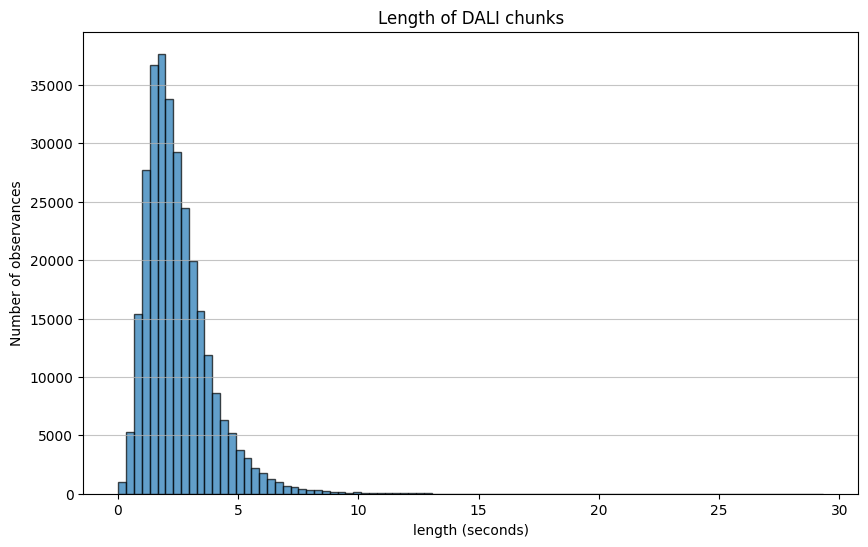

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def create_histogram_from_list(data_list, bins=10, title="Histogram", xlabel="Value", ylabel="Frequency", filename="histogram.png"):

    plt.figure(figsize=(10, 6))
    plt.hist(data_list, bins=bins, edgecolor='black', alpha=0.7) 
    
    # Add labels and title
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    
    # Add a grid for easier reading of values (optional)
    plt.grid(axis='y', alpha=0.75)
    
    # Save the plot to a file
    plt.savefig(filename)
    plt.show()
    return

print(f'Total chunks: {len(lens) + count}')
print(f'Number ommitted: {count} ({count/(len(lens) + count) * 100 :.3f}%)')

create_histogram_from_list(lens, 
                           bins=90, 
                           title='Length of DALI chunks', 
                           xlabel='length (seconds)', 
                           ylabel='Number of observances', 
                           filename='DALI-lines-hist.png')

The following iterates the following procedure for each track successfully downloaded from the DALI dataset
- Separates the vocals and instrument tracks using demucs
- Downsamples vocals track to 16kHz mono, .wav file
- Creates a separate .wav file of the vocals for each time interval identified in the df_lines file for the given track

Because this uses demucs to separate the vocals and instrument stems, each track take 30s or more to process. The whole dataset contains ~3000 tracks, which on my compute took 12 hours to process

In [40]:
import demucs.separate
from pydub import AudioSegment
from tqdm import tqdm

def extract_portions(times):
    # Define path names for demucs
    demucs_path = os.path.abspath(f"separated/mdx_extra/{root}")
    vocals_path = os.path.join(demucs_path, "vocals.wav")
    no_vocals_path = os.path.join(demucs_path, "no_vocals.wav")

    demucs.separate.main(["--two-stems", "vocals", "-n", "mdx_extra", audio_path])

    audio = AudioSegment.from_file(vocals_path)

    if audio.channels > 1:
        audio = audio.set_channels(1)

    if audio.frame_rate != 16000:
        audio = audio.set_frame_rate(16000)

    segment_names = []

    for i in range(len(times)):
        start = times[i][0] * 1000
        end = times[i][1] * 1000

        # Split the portion that contains vocals
        portion = audio[start:end]

        # Keep in order
        portion.export(f"T:\\chunked\\{dali_id}-{i}.wav", format="wav")
        segment_names.append(f'{dali_id}-{i}.wav')
    
    # Delete splits
    os.remove(vocals_path)
    os.remove(no_vocals_path)
    os.rmdir(demucs_path)

    return segment_names

Be warned: Running this cell takes an extremely long time

In [ ]:
dali_audio = "T:\\DALI-audio"
output_path = "T:\\chunked"

for dali_id in tqdm(os.listdir(dali_audio)):
    entry = dali_data[dali_id]

    df = pd.read_csv(os.path.join(dir_path, f"{dali_id}.csv"))

    for file in os.listdir(os.path.join(dali_audio, dali_id)):
        root, ext = os.path.splitext(file)

        if ext == '.wav':
            audio_path = f"T:\\DALI-audio\\{dali_id}\\{file}"
            break

    times = []

    for row in df.itertuples():
        start = row[2]
        end = row[3]
        times.append([start, end])

    file_names = extract_portions(times)

    # Add the file names to the lyrics dfs
    df['files'] = file_names
    df.to_csv(os.path.join(dir_path, f"{dali_id}.csv"), index=False)

This now creates the master metadata list for the DALI datasets. This is metadata-full-lines.csv and includes
- the word-timestamped and total transcript 
- WER and MER similarity between the two transcriptions
- filename

Additionally this cell automatically removes the few NaN entries that show up due to bad formatting of DALI

In [ ]:
import jiwer

dali_audio = "T:\\dl-project\\DALI-audio-raw"
dir_path = "C:\\Users\\dacla\\Documents\\DALI-dicts-redo" 

# Empty df
df_full = pd.DataFrame(columns=['words', 'start', 'end', 'transcript', 'WER', 'MER', 'filename'])

for dali_id in os.listdir(dali_audio):
    # Skip tracks not specifically in english. You'd think this work, but it doesn't actually get all of the 
    # non english track, further processing is needed
    if dali_data[dali_id].info['metadata']['language'] != 'english':
        continue
    
    #Load lyrics dfs from earlier, or use dali_dataset directly
    df_words = pd.read_csv(f"T:\\dl-project\\DALI-audio-raw\\{dali_id}\\lyrics.csv") 
    df_lines = pd.read_csv(os.path.join(dir_path, f"{dali_id}.csv"))
    
    # Some of the lyrics sets have 'NaN' as a word. It's unclear what this means. Delete it
    df_words.dropna(inplace=True)

    transcription_list = []
    wer_list = []
    mer_list = []

    for row in df_lines.itertuples():
        cols = df_lines.columns.tolist()
        words_ind = cols.index('words') + 1
        start_ind = cols.index('start') + 1
        end_ind = cols.index('end') + 1
        
        start = row[start_ind]
        end = row[end_ind]

        # Use the times of the word-level transcripts to select the portion
        df = df_words[(df_words['start'] >= start) & (df_words['end'] <= end) & (df_words['start'] < df_words['end'])].copy()

        # Create relative times within the extracted audio clip
        df['start'] = round(df['start'] - start, 3)
        df['end'] = round(df['end'] - start, 3)

        # Whisper expects timestamped lyrics to be of this form {word: str, start: flt, end: flt}
        transcription_list.append(df.to_dict(orient='records'))
        
        # Calculate WER between the word and line transcripts
        word_transcript = df['word'].astype(str).str.cat(sep=' ') 
        line_transcript = row[words_ind]

        if word_transcript and line_transcript:
            wer = jiwer.wer(word_transcript, line_transcript)
            mer = jiwer.mer(word_transcript, line_transcript)

            wer_list.append(wer)
            mer_list.append(mer)
        else:
            wer_list.append(None)
            mer_list.append(None)

    df_lines['transcript'] = transcription_list
    df_lines['WER'] = wer_list
    df_lines['MER'] = mer_list
    df_lines['filename'] = [f"{dali_id}-{i}.wav" for i in range(len(df_lines))]

    df_lines.to_csv(os.path.join(dir_path, f"{dali_id}.csv"), index=False)

    df_full = pd.concat([df_full, df_lines])


# Find entries for which 'words' is a string (there are some problems with a few tracks.) 
# Omit those for which this fails
is_str = df_full['words'].apply(lambda x: isinstance(x,str))
df_full = df_full[is_str]

# Save final df. This is the metadata file that is used to create the dataset for Whisper fine tuning
df_full.to_csv('metadata-full-lines.csv', index=False)


C:\Users\dacla\AppData\Local\Temp\ipykernel_21900\3271463781.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_full = pd.concat([df_full, df_lines])


There's a misalignment issue with the DALI dataset. Some of the word-level transcriptions do not agree with the line-level transcriptions. In addition, the word formatting in both is often incorrect by either (1) concatenating two words, (2) splitting a word into tokens, (3) misspellings/alternate spellings (ex. British vs. American english)

Below is a normalizesd sentence similarity metric between each of the entries.

Jared has done extensive work in better aligning the discrepencies between these two transcripts

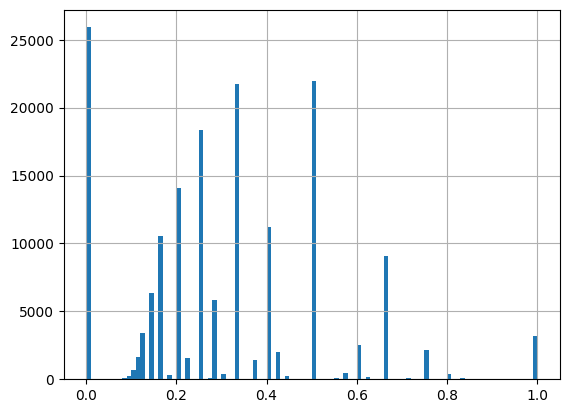

In [41]:
h = df_full['MER'].hist(bins=100)